<a href="https://colab.research.google.com/github/244107020170-png/machine-learning/blob/main/JS02_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JS02-01: Data Understanding & Preprocessing
Mata kuliah: Machine Learning

Tujuan: Melakukan EDA dan preprocessing pada dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


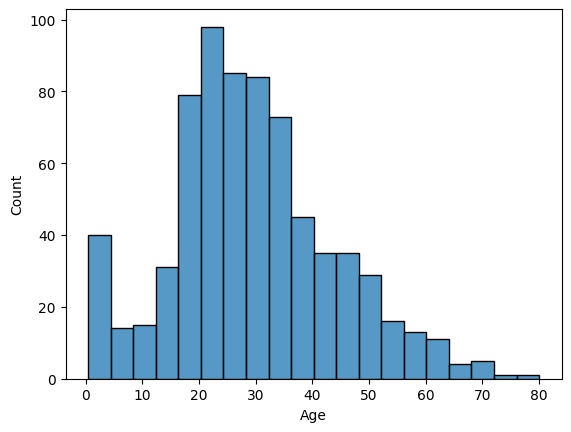

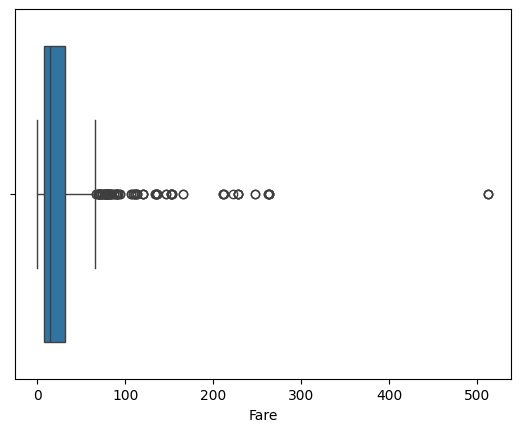

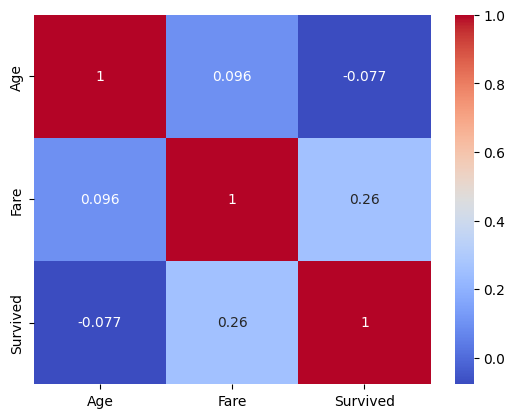

In [4]:
# Struktur data
df.info()
df.describe()

# Distribusi Age
sns.histplot(df['Age'], bins=20)
plt.show()

# Boxplot Fare
sns.boxplot(x=df['Fare'])
plt.show()

# Heatmap korelasi
sns.heatmap(df[['Age','Fare','Survived']].corr(), annot=True, cmap="coolwarm")
plt.show()

In [5]:
# Cek missing values
df.isnull().sum()

# Isi Age dengan median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Drop kolom Cabin (banyak NaN)
df.drop(columns=['Cabin'], inplace=True)

# Hapus duplikat
df.drop_duplicates(inplace=True)


/tmp/ipykernel_1404/2960611392.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [6]:
# Encode Sex
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

# One-hot encoding Embarked
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)


In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['Age','Fare']] = scaler.fit_transform(df[['Age','Fare']])


In [8]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Fare'] >= Q1 - 1.5*IQR) & (df['Fare'] <= Q3 + 1.5*IQR)]


In [10]:
X = df.drop(['Survived','Name','Ticket'], axis=1)  # buang kolom non-numerik
y = df['Survived']


In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)

print("Sebelum SMOTE:", y.value_counts())
print("Sesudah SMOTE:", pd.Series(y_res).value_counts())


Sebelum SMOTE: Survived
0    512
1    263
Name: count, dtype: int64
Sesudah SMOTE: Survived
0    512
1    512
Name: count, dtype: int64


# Kesimpulan
- Dataset sudah dibersihkan dari missing values & duplikat.
- Variabel kategorikal sudah di-encode.
- Data numerik sudah di-scale.
- Outlier sudah ditangani.
- Dataset siap digunakan untuk modelling Machine Learning.
